# Mod6L5 Data Challenge — Interpreting SLR Output (Dec 2023 NYC df)


**Format:** We Do (Instructor prompts) → You Do (Student work) → We Share (reflection)


**Goal:** Choose **one** dependent variable (**Y**) from the taxi dataset and build **three** simple linear regressions (each with a different single **X**) on **Dec 2023** rides. For each model, interpret the **coefficient**, **intercept**, **p‑value**, and **R‑squared** in plain business language. Then decide which model is “better” *for decision‑making* and why.


> **Reminder:** No train/test split or advanced metrics today. We focus on reading `.summary()` and communicating results.

## Instructor Section (10 mins)

**Follow these steps/considerations as you work**


1) **Pick a useful Y.** Which outcome would someone actually act on?  Who is the stakeholder for your Y?

*Avoid constructing Y that bakes in your X (e.g., avoid using `fare_amount` as X when Y = `total_amount` which already includes fare).*


2) **Choose three X’s** you can know at decision time, and that plausibly relate to Y. 

*You may engineer a feature to use in the model if you like*

*Note:  SLR needs numeric only inputs so variables like `PULocationID` can't be used (categorical → not for SLR today unless you transform; stick to numeric X for this exercise)*


3) **Interpretation lenses:**
- **Units:** Always state slope in units (e.g., “per mile”, “per minute”).
- **p‑value:** Does evidence suggest the slope ≠ 0?
- **R²:** How much of Y’s variation is captured by this X? Does that help the decision?
- **Intercept:** Is X=0 meaningful? If not, say it’s a math anchor.
- **Plausibility:** Does the direction/size make sense (e.g., longer trip → higher fare)?


4) **Better ≠ only higher R².** Weigh **interpretability**, **actionability**, and **evidence** (p‑value, CI) alongside R².

## YOU DO (40 mins)

### Step 1: Read in the Data & Choose your **Y** (dependent variable)

Pick one from the 2023_Yellow_Taxi_Trip_Data_20251015 csv file  

In [2]:
import statsmodels.api as sm
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("/Users/Marcy_Student/Desktop/marcy/DA2025_Lectures_Kevin/Mod6/data/2023_Yellow_Taxi_Trip_Data_20251015.csv", low_memory=False)

# Keep only numeric and relevant columns
num_cols = ['fare_amount', 'trip_distance', 'passenger_count', 'tpep_pickup_datetime', 'tip_amount']
df = df[num_cols].copy()
df = df.dropna()
for c in num_cols:
    df[c] = pd.to_numeric (
        df[c].astype(str).str.strip().str.replace(r'[^0-9.+\-eE]', '', regex=True),
        errors='coerce'
)
df['tpep_pickup_datetime'] = pd.to_datetime(df['tpep_pickup_datetime'], errors='coerce')

# Creates a new column 'hour' with the hour extracted
df['hour'] = df['tpep_pickup_datetime'].dt.hour

# Data had too many outliers, fares of upwards too 300,000 and negative fares too
df = df[
    (df['fare_amount'] > 0) &               # remove negative/zero fares
    (df['fare_amount'] < 250) &             # cap at $250 (reasonable max)
    (df['trip_distance'] > 0) &             # remove zero/negative distances
    (df['trip_distance'] < 100) &           # cap distance
    (df['passenger_count'] > 0) &           # must have passengers
    (df['passenger_count'] < 7)             # standard NYC cab limit
].copy()


df.head

<bound method NDFrame.head of          fare_amount  trip_distance  passenger_count  \
0               7.90           0.69              2.0   
1              10.00           1.10              3.0   
3              10.70           1.57              1.0   
4              21.90           3.00              2.0   
6              11.40           1.24              1.0   
...              ...            ...              ...   
3310901         6.50           0.71              1.0   
3310902        10.70           1.70              3.0   
3310903        82.10          21.60              1.0   
3310905        86.69           0.01              2.0   
3310906        65.30          16.67              1.0   

                 tpep_pickup_datetime  tip_amount  hour  
0       1970-01-01 03:20:12.023041139        3.00     3  
1       1970-01-01 03:20:12.023041139        0.00     3  
3       1970-01-01 03:20:12.023041139        0.00     3  
4       1970-01-01 03:20:12.023041139        3.00     3  
6      

### Step 2: Propose three candidate **X** predictors (numeric)

Pick three different X columns that are **numeric** and **known at decision time**.

In [3]:
Y = df['fare_amount']

X1 = sm.add_constant(df['trip_distance'])
X2 = sm.add_constant(df['passenger_count'])
X3 = sm.add_constant(df['hour'])

### Step 3: Fit three one‑variable models with the SAME Y and different Xs

In [ ]:
modelA = sm.OLS(Y, X1).fit()
modelB = sm.OLS(Y, X2).fit()
modelC = sm.OLS(Y, X3).fit()

print("Model A Summary (fare & trip_distance):")
print(modelA.summary())

print("\nModel B Summary (fare & passenger_count):")
print(modelB.summary())

print("\nModel C Summary (fare & hour):")
print(modelC.summary())

Model A Summary (fare & trip_distance):
                            OLS Regression Results                            
Dep. Variable:            fare_amount   R-squared:                       0.868
Model:                            OLS   Adj. R-squared:                  0.868
Method:                 Least Squares   F-statistic:                 1.981e+07
Date:                Mon, 03 Nov 2025   Prob (F-statistic):               0.00
Time:                        15:35:53   Log-Likelihood:            -9.8382e+06
No. Observations:             3015313   AIC:                         1.968e+07
Df Residuals:                 3015311   BIC:                         1.968e+07
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                    coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------
const 

### Step 4: Visual check for the “best” model candidate

Pick the model you currently prefer (based on business sense + evidence).
- Create a scatter of X vs. Y with the fitted line.

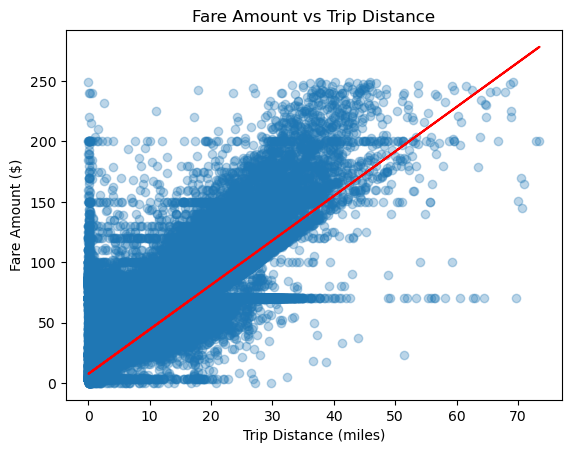

In [5]:
plt.scatter(df['trip_distance'], df['fare_amount'], alpha=0.3)
plt.plot(df['trip_distance'], modelA.predict(X1), color='red')
plt.title("Fare Amount vs Trip Distance")
plt.xlabel("Trip Distance (miles)")
plt.ylabel("Fare Amount ($)")
plt.show()

### Step 5: Interpret Each Model (write in plain English)
Fill the three blocks below. Use **units** and **percentage points (pp)** where relevant.

- **Slope (β₁):** “For each +1 unit of X, Y changes by …”
- **Intercept (β₀):** meaningful or just a math anchor? Explain.
- **p‑value:** is there evidence the slope ≠ 0?
- **R²:** how much variation does this X explain?
- **Judgment:** is the effect size **practically** meaningful (tie to business)?

### Model A — Y = {{Fare Amount}} ~ X1 = {{Trip Distnace}}
- Slope (β₁): Around +3.69 per mile, this means each additional mile add $3.69 to the fare. 
- Intercept (β₀): The minimum fare, when miles is at 0 is $7.51
- p‑value (slope): very close to 0, meaning  theres a strong statistical evidence that fare increases with distance. 
- 95% CI for slope: (3.683 , 3.687), we can 95% sure that each additional mile adds between 3.683 and 3.687 to fare.

- R²: 0.868, trip distance explains 86.8% of the variation in fare.
- Business readout (units): Longer trips consistently cost more. Distance is a strong factor in determiting price. 
- One limitation: Doesn't account for traffic delays, or waiting time. 

### Model B — Y = {{Fare Amount}} ~ X2 = {{Passenger Count}}
- Slope (β₁): 1.06, for each additional passenger the fare increased by about $1.06. 
- Intercept (β₀): When passenger_counts is 0, which could not happen, the model predicts a fare of $18.31
- p‑value (slope): Less then 0.0001, meaning there is strong evidence that fare amount changes with passenger count. 
- 95% CI for slope: (1.037, 1.080). We can be 95% confident the true increase per extra passenger is between $1.04 and $1.08
- R²: 0.003, passenger count explains just 0.3% of fare variation
- Business readout (units): Additional passengers has a statistically detectable effect but not a meaningful one for fare prediction. 
- One limitation: Passenger count doesn't causally affect fare amount. It's not an ideal variable to use to predict pricing. 

### Model C — Y = {{Fare Amount}} ~ X3 = {{Hour}}
- Slope (β₁): When hour is 0, or midnight the model predicts the fare to be at $50.26
- Intercept (β₀): Each additional hour later in the day is on average $10.14 cheaper
- p‑value (slope): 0.000, data gives strong evidence of a relationship between time of day and fare amount. 
- 95% CI for slope: (–15.22 , –5.06) → the true hourly change is likely between –$15 and –$5.
- R²: 0.000, time of day explains none of the variation in fare amount. 
- Business readout (units): While fares tend to vary across the day, hour alone is not useful for fare prediction. 
- One limitation: Doesn't count for all other variables. 

## We Share (10 mins) — Reflection & Decision (write 1-2 short paragraphs)

1) **Which model is “better” for a stakeholder decision and why?**
- Weigh **evidence** (p‑value, CI), **explanatory power** (R²), **interpretability**, and **business impact** (units, MDE if relevant).
Model A (Fare Amount - Trip Distance) is definitely the best one. It makes sense both statistically and in real life, longer trips cost more money. The model has a really high R² around 0.87, meaning distance explains most of the changes in fare, and the p-value is basically zero, showing a strong relationship. The slope of about $3.69 per mile lines up with what we know about how taxi fares are priced in NYC. The other models (passenger count and hour) were technically “significant,” but they barely explained anything about fares and don’t really help with decision-making.
2) **What would you do next week to strengthen trust in this model?**
- (Preview) time‑based validation, hold‑out testing, segment checks, adding more plausible X’s, checking assumptions.
Next, I’d want to test the model on another month or a separate data sample to make sure it still holds up. I’d also add other variables like trip duration or time of day to see if they improve predictions, and check the residuals to make sure the assumptions of linear regression are met. Basically, I’d keep refining it so it’s not just accurate, but something we could actually rely on for real decisions.